# Structured Magnitude Pruning (L1 Norm) on CIFAR-10 Models

## Objective

This notebook implements **structured post-training pruning based on weight magnitude (L1 norm)** for two neural network architectures trained on CIFAR-10:

- Multi-Layer Perceptron (MLP)
- VGG-style Convolutional Neural Network (VGG)

The goal is to remove neurons and convolutional filters with low importance while preserving predictive performance.

The pruning process follows an **iterative post-training structured pruning pipeline**:

1. Load trained baseline model
2. Compute saliency scores
3. Remove low-importance neurons/filters
4. Fine-tune the remaining network
5. Evaluate performance degradation

The pruning criterion follows the **L1 magnitude heuristic**:

For neuron/filter \(j\):

\[S_j = \sum_i |w_{ij}|\]

where:

- \(S_j\) is the saliency score
- \(w_{ij}\) are the weights associated with neuron/filter \(j\)

Low saliency indicates low contribution to the network output.

In [39]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
import pandas as pd
from utils import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

cuda


## Load model

In [7]:
models_dir = Path('model_dir')
PATH_MLP = models_dir / 'cifar_mlp.pt'
PATH_VGG = models_dir / 'cifar_vgg.pt'


mlp_model = torch.load(PATH_MLP, weights_only=False)
vgg_model = torch.load(PATH_VGG, weights_only=False)

## Load determininstic split

To ensure fair comparison across pruning experiments, a deterministic train-validation split is reused.

The split indices were generated during baseline training and saved to disk.

In [8]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616))])

full_trainset  = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


split = torch.load("data/cifar10_split.pt", weights_only=False)

train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

## Baseline Evaluation

Before pruning, the original model performance is measured to establish a reference point.

In [9]:
y_true, y_pred_mlp, y_probs_mlp = evaluate_model(
    mlp_model,
    testloader,
    device
)

y_true, y_pred_vgg, y_probs_vgg = evaluate_model(
    vgg_model,
    testloader,
    device
)

In [10]:
baseline_metrics_mlp = compute_metrics(
    y_true,
    y_pred_mlp
)

baseline_metrics_mlp

{'accuracy': 0.5732,
 'balanced_accuracy': 0.5732,
 'precision_macro': 0.5799084414188164,
 'precision_weighted': 0.5799084414188165,
 'recall_macro': 0.5732,
 'recall_weighted': 0.5732,
 'f1_macro': 0.5752448710631597,
 'f1_weighted': 0.5752448710631596,
 'cohen_kappa': 0.5257777777777778,
 'mcc': 0.5260541925110951}

In [11]:
baseline_metrics_vgg = compute_metrics(
    y_true,
    y_pred_vgg
)

baseline_metrics_vgg

{'accuracy': 0.7852,
 'balanced_accuracy': 0.7851999999999999,
 'precision_macro': 0.7905888762866331,
 'precision_weighted': 0.7905888762866331,
 'recall_macro': 0.7851999999999999,
 'recall_weighted': 0.7852,
 'f1_macro': 0.78376605711121,
 'f1_weighted': 0.7837660571112101,
 'cohen_kappa': 0.7613333333333334,
 'mcc': 0.762260305799341}

## Structured L1 Saliency

Neuron importance is computed using the L1 norm of the outgoing weights.

For neuron \(j\):

\[
S_j = \sum_i |w_{ij}|
\]

Neurons with lower saliency are considered less important and are selected for removal.

In [12]:
def compute_l1_saliency_linear(layer):

    W = layer.weight.data

    # neuron importance
    saliency = torch.sum(torch.abs(W), dim=1)

    return saliency

## Neuron Ranking

The neurons are ranked according to saliency and the least important fraction is removed.

In [13]:
def get_keep_indices(
    layer,
    pruning_ratio=0.3
):

    saliency = compute_l1_saliency_linear(layer)

    n_neurons = saliency.shape[0]

    n_keep = int(
        n_neurons * (1 - pruning_ratio)
    )

    keep_idx = torch.argsort(
        saliency,
        descending=True
    )[:n_keep]

    return keep_idx.sort()[0]

## Structured Layer Reconstruction

Instead of masking weights to zero, the network architecture is physically reconstructed.

This reduces:

- parameter count
- memory consumption
- inference latency

In [14]:
def prune_linear_layer(
    layer,
    keep_idx
):

    old_weight = layer.weight.data
    old_bias = layer.bias.data

    new_layer = nn.Linear(
        in_features=old_weight.shape[1],
        out_features=len(keep_idx)
    )

    new_layer.weight.data = (
        old_weight[keep_idx]
    )

    new_layer.bias.data = (
        old_bias[keep_idx]
    )

    return new_layer

In [15]:
keep_idx = get_keep_indices(
    mlp_model.classifier[1],
    pruning_ratio=0.3
)

pruned_fc1 = prune_linear_layer(
    mlp_model.classifier[1],
    keep_idx
)

## Fine-Tuning After Pruning

After structured pruning, the model undergoes fine-tuning to recover predictive performance.

In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    mlp_model.parameters(),
    lr=1e-4,
    momentum=0.9
)

In [ ]:
mlp_model_30 = train_model(
    mlp_model,
    trainloader,
    valloader,
    epochs=5
)

100%|██████████| 665/665 [00:13<00:00, 50.13it/s] 


Epoch [1/5] Train Loss: 0.8145 | Val Loss: 0.6303 | Val Acc: 79.23%


100%|██████████| 665/665 [00:12<00:00, 51.99it/s] 


Epoch [2/5] Train Loss: 0.7586 | Val Loss: 0.6697 | Val Acc: 77.60%


100%|██████████| 665/665 [00:13<00:00, 50.90it/s] 


Epoch [3/5] Train Loss: 0.7259 | Val Loss: 0.7122 | Val Acc: 75.51%


100%|██████████| 665/665 [00:15<00:00, 41.95it/s]


Epoch [4/5] Train Loss: 0.6950 | Val Loss: 0.7117 | Val Acc: 75.91%


100%|██████████| 665/665 [00:13<00:00, 50.30it/s] 


Epoch [5/5] Train Loss: 0.6510 | Val Loss: 0.7333 | Val Acc: 75.55%


## Evaluation After Pruning

Performance is re-measured to assess degradation caused by pruning.

In [19]:
y_true, y_pred, _ = evaluate_model(
    mlp_model,
    testloader,
    device
)

mlp_pruned_metrics = compute_metrics(
    y_true,
    y_pred
)

mlp_pruned_metrics

{'accuracy': 0.5785,
 'balanced_accuracy': 0.5785000000000001,
 'precision_macro': 0.5835376747908055,
 'precision_weighted': 0.5835376747908056,
 'recall_macro': 0.5785000000000001,
 'recall_weighted': 0.5785,
 'f1_macro': 0.5800324981560994,
 'f1_weighted': 0.5800324981560995,
 'cohen_kappa': 0.5316666666666665,
 'mcc': 0.5319320724167619}

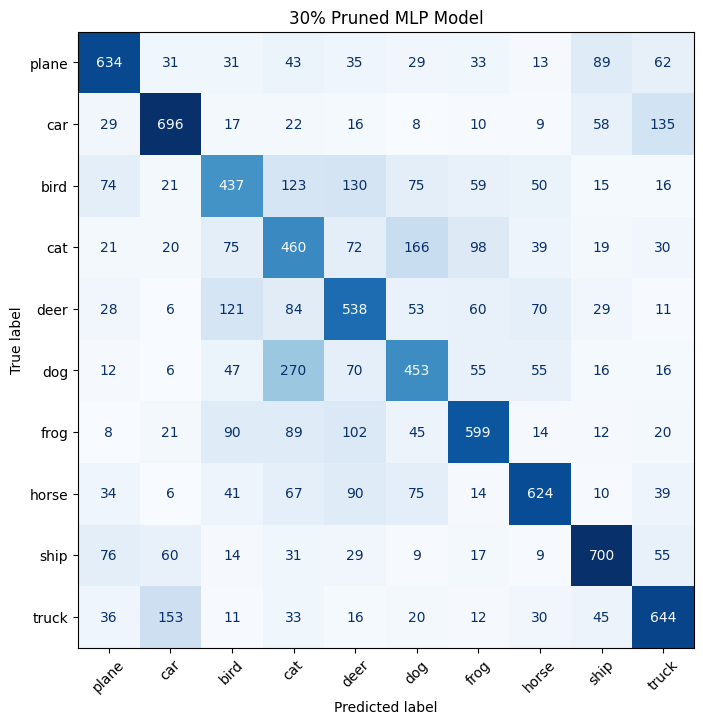

In [20]:
plot_confusion_matrix(
    y_true,
    y_pred,
    classes,
    "30% Pruned MLP Model"
)

## Baseline vs Pruned Comparison

In [21]:
comparison = pd.DataFrame({
    "Baseline": baseline_metrics_mlp,
    "Pruned": mlp_pruned_metrics
})

comparison

,Baseline,Pruned
accuracy,0.573200,0.578500
balanced_accuracy,0.573200,0.578500
precision_macro,0.579908,0.583538
precision_weighted,0.579908,0.583538
recall_macro,0.573200,0.578500
recall_weighted,0.573200,0.578500
f1_macro,0.575245,0.580032
f1_weighted,0.575245,0.580032
cohen_kappa,0.525778,0.531667
mcc,0.526054,0.531932


# Pruning for the VGG

## Convolutional Filter Saliency

For convolutional layers, pruning is applied at the **filter level**.

Each output filter \(j\) is assigned an importance score using the L1 norm:

\[
S_j =
\sum_{c,h,w}
|W_{j,c,h,w}|
\]

where:

- \(j\) = output filter
- \(c\) = input channels
- \(h,w\) = kernel dimensions

Filters with smaller saliency are considered less important and removed.

In [22]:
def compute_conv_saliency(conv_layer):

    W = conv_layer.weight.data

    saliency = torch.sum(
        torch.abs(W),
        dim=(1,2,3)
    )

    return saliency

## Filter Ranking

Filters are ranked according to saliency and the least important percentage is removed.

In [23]:
def get_conv_keep_indices(
    conv_layer,
    pruning_ratio=0.3
):

    saliency = compute_conv_saliency(
        conv_layer
    )

    n_filters = saliency.shape[0]

    n_keep = int(
        n_filters * (1 - pruning_ratio)
    )

    keep_idx = torch.argsort(
        saliency,
        descending=True
    )[:n_keep]

    return keep_idx.sort()[0]

## Structured Convolutional Pruning

Structured pruning physically removes convolutional filters.

Given a convolution:

\[
Conv2D(C_{in}, C_{out})
\]

Removing filters reduces:

\[
C_{out}
\]

The subsequent convolution must also be modified by removing the corresponding input channels.

In [24]:
def prune_conv_layer(
    conv_layer,
    keep_idx
):

    old_weight = conv_layer.weight.data
    old_bias = conv_layer.bias.data

    new_out_channels = len(keep_idx)

    new_conv = nn.Conv2d(
        in_channels=conv_layer.in_channels,
        out_channels=new_out_channels,
        kernel_size=conv_layer.kernel_size,
        stride=conv_layer.stride,
        padding=conv_layer.padding,
        bias=True
    )

    new_conv.weight.data = (
        old_weight[keep_idx]
    )

    new_conv.bias.data = (
        old_bias[keep_idx]
    )

    return new_conv

In [25]:
def adjust_next_conv_layer(
    next_conv,
    keep_idx
):

    old_weight = next_conv.weight.data

    new_conv = nn.Conv2d(
        in_channels=len(keep_idx),
        out_channels=next_conv.out_channels,
        kernel_size=next_conv.kernel_size,
        stride=next_conv.stride,
        padding=next_conv.padding,
        bias=True
    )

    new_conv.weight.data = (
        old_weight[:, keep_idx]
    )

    new_conv.bias.data = (
        next_conv.bias.data
    )

    return new_conv

## Batch Normalization Adaptation

Because convolutional filters are removed, corresponding BatchNorm channels must also be removed.

In [26]:
def prune_batchnorm_layer(
    bn_layer,
    keep_idx
):

    new_bn = nn.BatchNorm2d(
        len(keep_idx)
    )

    new_bn.weight.data = (
        bn_layer.weight.data[keep_idx]
    )

    new_bn.bias.data = (
        bn_layer.bias.data[keep_idx]
    )

    new_bn.running_mean = (
        bn_layer.running_mean[keep_idx]
    )

    new_bn.running_var = (
        bn_layer.running_var[keep_idx]
    )

    return new_bn

## VGG Structured Pruning Pipeline

The following procedure performs:

1. Filter ranking
2. Filter removal
3. BatchNorm adaptation
4. Channel propagation to the next layer

In [27]:
# Prune first convolutional layer only.
conv1 = vgg_model.features[0]
bn1 = vgg_model.features[1]

keep_idx = get_conv_keep_indices(
    conv1,
    pruning_ratio=0.3
)

In [28]:
# Prune
new_conv1 = prune_conv_layer(
    conv1,
    keep_idx
)

new_bn1 = prune_batchnorm_layer(
    bn1,
    keep_idx
)

In [29]:
# Adjust next conv
next_conv = vgg_model.features[4]

new_next_conv = adjust_next_conv_layer(
    next_conv,
    keep_idx
)

In [30]:
# Replace modules
vgg_model.features[0] = new_conv1
vgg_model.features[1] = new_bn1
vgg_model.features[4] = new_next_conv

In [ ]:
def get_last_conv_channels(model):

    for layer in reversed(model.features):

        if isinstance(layer, nn.Conv2d):
            return layer.out_channels

    raise ValueError(
        "No Conv2d layer found."
    )

last_channels = get_last_conv_channels(
    vgg_model
)

print(last_channels)

vgg_model.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(last_channels, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 10)
)

512


## Fine-Tuning the Pruned VGG

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    vgg_model.parameters(),
    lr=1e-4
)

In [38]:
images, _ = next(iter(trainloader))
images = images.to(device)

x = vgg_model.features(images)

print("features:", x.shape)

x = vgg_model.avgpool(x)

print("avgpool:", x.shape)

x = torch.flatten(x, 1)

print("flatten:", x.shape)

x = vgg_model.classifier(x)

print("classifier output:", x.shape)

features: torch.Size([64, 512, 1, 1])
avgpool: torch.Size([64, 512, 1, 1])
flatten: torch.Size([64, 512])
classifier output: torch.Size([64, 10])


In [36]:
print(vgg_model)

CIFAR10VGG(
  (features): Sequential(
    (0): Conv2d(3, 44, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(44, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(44, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo

In [37]:
images, labels = next(iter(trainloader))

images = images.to(device)

x = images

for i, layer in enumerate(vgg_model.features):

    print(i, type(layer), x.shape)

    x = layer(x)

0 <class 'torch.nn.modules.conv.Conv2d'> torch.Size([64, 3, 32, 32])
1 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> torch.Size([64, 44, 32, 32])
2 <class 'torch.nn.modules.activation.ReLU'> torch.Size([64, 44, 32, 32])
3 <class 'torch.nn.modules.pooling.MaxPool2d'> torch.Size([64, 44, 32, 32])
4 <class 'torch.nn.modules.conv.Conv2d'> torch.Size([64, 44, 16, 16])
5 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> torch.Size([64, 128, 16, 16])
6 <class 'torch.nn.modules.activation.ReLU'> torch.Size([64, 128, 16, 16])
7 <class 'torch.nn.modules.pooling.MaxPool2d'> torch.Size([64, 128, 16, 16])
8 <class 'torch.nn.modules.conv.Conv2d'> torch.Size([64, 128, 8, 8])
9 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> torch.Size([64, 256, 8, 8])
10 <class 'torch.nn.modules.activation.ReLU'> torch.Size([64, 256, 8, 8])
11 <class 'torch.nn.modules.conv.Conv2d'> torch.Size([64, 256, 8, 8])
12 <class 'torch.nn.modules.batchnorm.BatchNorm2d'> torch.Size([64, 256, 8, 8])
13 <class 'torch.nn.module

In [35]:
vgg_model, train_loss, val_loss, val_acc = train_model(
    vgg_model,
    trainloader,
    valloader,
    epochs=5
)

  0%|          | 0/665 [00:07<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "c:\Users\ivanm\miniconda3\envs\deepLearning\Lib\site-packages\IPython\core\interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\ivanm\AppData\Local\Temp\ipykernel_22920\887836538.py", line 1, in <module>
    vgg_model, train_loss, val_loss, val_acc = train_model(
                                               ^^^^^^^^^^^^
  File "c:\Users\ivanm\Documents\Iscte\PG_Aprendizagem_Automatica\Otimizacao_Computacional\AI_Pruning\utils.py", line 135, in train_model
  File "c:\Users\ivanm\miniconda3\envs\deepLearning\Lib\site-packages\torch\nn\modules\module.py", line 1775, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ivanm\miniconda3\envs\deepLearning\Lib\site-packages\torch\nn\modules\module.py", line 1786, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

## Evaluation after pruning

In [ ]:
vgg_true, vgg_pred, _ = evaluate_model(
    vgg_model,
    testloader,
    device
)

vgg_pruned_metrics = compute_metrics(
    vgg_true,
    vgg_pred
)

vgg_pruned_metrics